<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/missions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Sources**

In [ ]:
!pip install astropy astroquery matplotlib numpy requests -q
from astropy import units as u
from astropy.coordinates import SkyCoord
from astroquery.simbad import Simbad
from astropy import coordinates
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
import matplotlib.pyplot as plt
from astroquery.heasarc import Heasarc
%matplotlib inline

#### **Define object and get skycoordinates**

In [49]:
# Define object
object_name = 'M31'
#object_name = 'Abell 2125'

In [50]:
# Get and set skycoordinates of object
skyobject = Simbad.query_object(object_name)
ra_hms = skyobject['RA'][0]
dec_dms = skyobject['DEC'][0]
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
print(skyobject)
print("\nCoordinates:")
print("RA (h:m:s):", ra_hms)
print("DEC (d:m:s):", dec_dms)

MAIN_ID      RA          DEC      RA_PREC ... COO_WAVELENGTH     COO_BIBCODE     SCRIPT_NUMBER_ID
          "h:m:s"      "d:m:s"            ...                                                    
------- ------------ ------------ ------- ... -------------- ------------------- ----------------
  M  31 00 42 44.330 +41 16 07.50       7 ...              I 2006AJ....131.1163S                1

Coordinates:
RA (h:m:s): 00 42 44.330
DEC (d:m:s): +41 16 07.50


#### **HEASARC (X-Ray, Gamma Ray)**

HEASARC (High Energy Astrophysics Science Archive Research Center): data from missions observing the high-energy universe, like X-rays and gamma rays. Like black holes, supernovas, and active galaxies
* Missions: Chandra, XMM-Newton, Swift, Fermi, NuSTAR
* Website: heasarc.gsfc.nasa.gov

In [4]:
# Query all available missions from library
from astroquery.heasarc import Heasarc
heasarc = Heasarc()
missions = heasarc.query_mission_list()
print(missions)

 Mission     Table                                  Table Description                               
---------- ---------- ------------------------------------------------------------------------------
     AGILE   agilecat                       First AGILE Catalog of High-Confidence Gamma-Ray Sources
     AGILE agileupvar              Updated AGILE Catalog of Bright Gamma-Ray Sources and Variability
     AKARI   akaribsc                      AKARI/FIS All-Sky Survey Bright Source Catalog, Version 1
     AKARI   akaripsc                       AKARI/IRC All-Sky Survey Point Source Catalog, Version 1
       ANS ansuvpscat                            ANS Ultraviolet Photometry Catalog of Point Sources
   ARIEL V    ariel3a                                                        3rd Ariel-V SSI Catalog
   ARIEL V     ariel5                                                        Ariel V All-Sky Monitor
      ASCA ascaegclus                           ASCA Elliptical Galaxies and Galaxy Cluster

In [16]:
# Select mission
mission='chanmaster'

Main X-ray missions:
- `chanmaster`: Chandra Master Catalog
- `csc2master`: Chandra Source Catalog 2.0
- `xmmmaster`: XMM-Newton Master Catalog
- `xmmssc`: XMM-Newton Serendipitous Source Catalog
- `swiftmastr`: Swift Master Catalog
- `swiftxrtspec`: Swift-XRT Spectral Database
- `rass2rxs`: ROSAT All-Sky Survey Catalogs
- `exomaster`: EXOSAT Master Catalog
- `numaster`: NuSTAR Master Catalog

For other wavelengths/multi-wavelength:
- `fermimastr`: Fermi Master Catalog (gamma-ray)
- `intmaster`: INTEGRAL Master Catalog (gamma-ray)
- `suzamaster`: Suzaku Master Catalog
- `hstadvize`: Hubble Space Telescope Pointed Observations (optical)
- `jwstmaster`: James Webb Space Telescope Master Catalog (infrared)

In [7]:
# Query observations from one mission (PI - Principal Investigator. Lead scientist for observation)
chanmaster_data = heasarc.query_object('*', mission)
print(chanmaster_data)

OBSID        STATUS        ...                    PI                    PUBLIC_DATE
                           ...                                              mjd    
----- -------------------- ... ---------------------------------------- -----------
 6616 archived             ... Miller                                         54159
 7587 archived             ... Canizares                                      54502
28092 untriggered          ... Canizares                                          0
29852 untriggered          ... Canizares                                          0
28354 unobserved           ... Kargaltsev                                         0
30481 untriggered          ... Canizares                                          0
28775 untriggered          ... Canizares                                          0
13814 archived             ... Kuntz                                          56576
13842 archived             ... Baganoff                                     

In [8]:
# Query a specific object in mission
object_data = heasarc.query_object(object_name, mission='chanmaster')
print(object_data)

OBSID        STATUS        ... PUBLIC_DATE     SEARCH_OFFSET_   
                           ...     mjd                          
----- -------------------- ... ----------- ---------------------
 2207 archived             ...       52550  4.158 (Abell 2125)\n
 6891 archived             ...       54194 12.732 (Abell 2125)\n
 7708 archived             ...       54631  0.082 (Abell 2125)\n


In [9]:
# Reduce to specific columns for object
specific_data = heasarc.query_object(object_name, mission='chanmaster', fields='OBSID,ra,dec,exposure')
print(specific_data)

OBSID     RA      DEC    EXPOSURE     SEARCH_OFFSET_   
         deg      deg       s                          
----- --------- -------- -------- ---------------------
 2207 235.18750 66.21667    82590  4.158 (Abell 2125)\n
 6891 235.62167 66.43692    31450 12.732 (Abell 2125)\n
 7708 235.30542 66.26611     4790  0.082 (Abell 2125)\n


In [ ]:
# Initialize the Heasarc class
heasarc = Heasarc()

# Coordinates for galaxy
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=('hourangle', 'deg'), frame='icrs')
# coord = SkyCoord(ra="15h41m14.8s", dec="+66d16m03s", unit=('hourangle', 'deg'), frame='icrs')

# Query Chandra data
# Using 'chanmaster' for the Chandra Master Catalog
chandra_result = heasarc.query_region(
    coord,
    mission='chanmaster',
    radius='0.2 deg'  # Increased radius to ensure we catch all relevant observations
)

# Print the result
if chandra_result is not None and len(chandra_result) > 0:
    print(f"Found {len(chandra_result)} Chandra observations")
    for obs in chandra_result:
        print(f"\nObservation ID: {obs['OBSID']}")
        print(f"Exposure Time: {obs['EXPOSURE']} seconds")
else:
    print("No Chandra observations found")

#### **IRSA**

IRSA (Infrared Science Archive): This archive focuses on infrared data, which reveals cooler objects in space, like dust clouds where stars are born, distant galaxies, and planets in our solar system
* Spitzer, WISE, Herschel, SOFIA
* Website: irsa.ipac.caltech.edu

In [60]:
# Query all available missions from library
from astroquery.ipac.irsa import Irsa
catalogs = Irsa.list_catalogs()
print(catalogs)

{'m31irac': 'M31 IRAC Catalog', 'spitzer.m31irac_image': 'M31IRAC Images', 'mipslg': 'MIPS Local Galaxies Catalog', 'spitzer.mips_lg_images': 'MIPS Local Galaxies (MIPS_LG) Images', 'spitzer.mipsgal_images': 'A 24 and 70 Micron Survey of the Inner Galactic Disk with MIPS (MIPSGAL) Images', 'mipsgala': 'MIPSGAL Archive', 'mipsgalc': 'MIPSGAL Catalog', 'spitzer.s5_spectra': 'S5 Spectra', 'spitzer.s5_lores': 'Spitzer S5 Lo-res', 'spitzer.s5_hires': 'Spitzer S5 Hi-res', 's4gcat': 'S4G Catalog', 's4getg': 'S4G Early Type Galaxy Catalog', 'spitzer.s4g_images': 'The Spitzer Survey of Stellar Structure in Galaxies (S4G) Images', 'spitzer.s4g_details': 'Spitzer S4G Details Metadata', 'safires70': 'SAFIRES MIPS 70 micron Catalog', 'safires160': 'SAFIRES MIPS 160 micron Catalog', 'spitzer.safires_images': 'Spitzer Archival FIR Extragalactic Survey (SAFIRES) Images', 'spitzer.safires_science': 'Spitzer SAFIRES Science Image Metadata', 'spitzer.safires_ancillary': 'Spitzer SAFIRES Ancillary Image M

In [61]:
# Select catalog or mission
collection = 'spitzer_seip'

**Infrared Surveys (images and catalogs)**
* Spitzer Source Catalogs:
    * `seip_science`: The source catalog from SEIP
    * `spitzer_c2d`: Catalog from the c2d Legacy Survey
    * `spitzer_glimpse`: Catalog from the GLIMPSE Survey

* Spitzer Image Collections (used with query_sia):
    * `spitzer_seip`: Enhanced Imaging Products
    * `spitzer_sha`: Spitzer Heritage Archive
    * `spitzer_c2d`: c2d Legacy Survey Images
    * `spitzer_glimpse`: GLIMPSE Survey Images

* WISE Source Catalogs:
    * `allwise`: The AllWISE Source Catalog (combines data from WISE All-Sky, 3-Band Cryo, and Post-Cryo surveys)
    * `wise_allsky`: The original WISE All-Sky Release Source Catalog
    * `neowise`: NEOWISE-R Single Exposure Source Database

* WISE Image Collections (used with query_sia):
    * `wise_allwise`: AllWISE Atlas Images
    * `wise_allsky`: WISE All-Sky Release Atlas Images
    * `wise_neowiser`: NEOWISE-R Atlas Images

* 2MASS Source Catalogs:
    * `fp_psc`: 2MASS Point Source Catalog
    * `fp_xsc`: 2MASS Extended Source Catalog

* 2MASS Image Collections:
    * `2mass`: 2MASS All-Sky Atlas Images

* IRAS Source Catalogs:
    * `iras_psc`: IRAS Point Source Catalog
    * `iras_fsc`: IRAS Faint Source Catalog

**Near-Infrared Surveys**
* 2MASS Source Catalogs:
    * `fp_psc`: 2MASS Point Source Catalog
    * `fp_xsc`: 2MASS Extended Source Catalog
* 2MASS Image Collections:
    * `2mass`: 2MASS Atlas Images

* UKIDSS Source Catalogs:
    * `ukidss`: UKIRT Infrared Deep Sky Survey Catalog
* UKIDSS Image Collections:
    * `ukidss_las`: UKIDSS Large Area Survey Images
    * `ukidss_gcs`: UKIDSS Galactic Clusters Survey Images

**Dust/Galactic Structure**
* IRAS Source Catalogs:
    * `iras_psc`: IRAS Point Source Catalog
    * `iras_fsc`: IRAS Faint Source Catalog
* IRAS Image Collections:
    * `issa`: IRAS Sky Survey Atlas Images
    
* Dust Maps:
    * `irsa_dust`: IRAS/COBE Dust Maps (catalog-like service)

**Recent/Ongoing Surveys**
* NEOWISE Catalogs:
    * `neowise`: NEOWISE-R Single Exposure Source Database
* NEOWISE Images:
    * `wise_neowiser`: NEOWISE-R Atlas Images

* unWISE Catalogs:
    * `unwise`: unWISE Source Catalog
* unWISE Images:
    * `unwise_atlas`: unWISE Atlas Images

* COSMOS Catalogs:
    * `cosmos`: COSMOS Source Catalog
* COSMOS Images:
    * `cosmos_tiles`: COSMOS Survey Tiles

**Specific Scientific Studies**
* PTF Catalogs:
    * `ptf`: Palomar Transient Factory Source Catalog
* PTF Images:
    * `ptf_images`: PTF Survey Images

* GOALS Data:
    * `mass_goals`: Great Observatories All-sky LIRG Survey Catalog

* AKARI Catalogs:
    * `akari`: AKARI/IRC Point Source Catalogue
* AKARI Images:
    * `akari_images`: AKARI Survey Images

*Note: Not all collections have both catalog and image services available. Some might only provide catalogs, while others might only provide images or have different access methods.*

*Note: IRSA's Simple Image Access (SIA) protocol to find images. It searches within 1 arcminute radius around your specified coordinates. The query returns metadata about available images in that region.*

*Note: The main difference between AllWISE and WISE All-Sky is that AllWISE combines multiple surveys and provides improved sensitivity and accuracy compared to the original WISE All-Sky Survey.*

In [67]:
# Image access queries from IRSA for object images (in 'coord') from a given telescope (in 'collection')
obj_details = Irsa.query_sia(
    pos=(coord, 1 * u.arcmin),  # Position and search radius
    collection=collection    # Specifying the Spitzer SEIP collection
)
obj_details

<DALResultsTable length=82>
    s_ra      s_dec        facility_name      ... o_ucd  upload_row_id
    deg        deg                            ...                     
  float64    float64           object         ... object     int64    
----------- --------- ----------------------- ... ------ -------------
187.2745134 2.0575142 Spitzer Space Telescope ...                    1
187.2745134 2.0575142 Spitzer Space Telescope ...                    1
187.2745134 2.0575142 Spitzer Space Telescope ...                    1
187.2745134 2.0575142 Spitzer Space Telescope ...                    1
187.2745134 2.0575142 Spitzer Space Telescope ...                    1
187.2745134 2.0575142 Spitzer Space Telescope ...                    1
187.2745134 2.0575142 Spitzer Space Telescope ...                    1
187.2745134 2.0575142 Spitzer Space Telescope ...                    1
187.2745134 2.0575142 Spitzer Space Telescope ...                    1
        ...       ...                     ... ...

In [69]:
# Turn details into a table
#images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection=collection).to_table()
#images

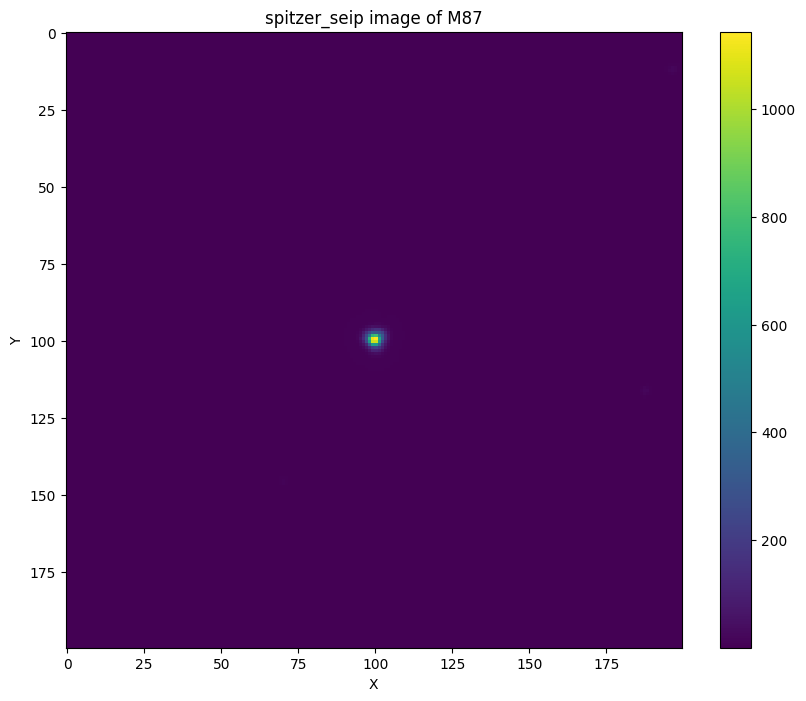

(<matplotlib.image.AxesImage at 0x7ab6aa1c3e80>,
 None)

In [68]:
# Open cutout image for one science image
images = Irsa.query_sia(pos=(coord, 1 * u.arcmin), collection=collection).to_table()
image = images[images['dataproduct_subtype'] == 'science'][0]
with fits.open(image['access_url'], use_fsspec=True) as hdul:
    cutout = Cutout2D(hdul[0].section, position=coord, size=2 * u.arcmin, wcs=WCS(hdul[0].header))

plt.figure(figsize=(10, 8)).add_subplot().set(title=f'{collection} image of {object_name}', xlabel='X', ylabel='Y')
plt.imshow(cutout.data, cmap='viridis'), plt.colorbar(), plt.show()

In [48]:
# How many science picture are there in the catalog for the specific object?
science_images_count = len(images[images['dataproduct_subtype'] == 'science'])
print("Number of science images:", science_images_count)

Number of science images: 18




---



In [ ]:
# Query the SEIP source catalog
seip_sources = Irsa.query_region(coord, catalog='seip_science', radius=1*u.arcmin)

In [ ]:
# For catalog queries:
allwise_sources = Irsa.query_region(coord, catalog='allwise', radius=1*u.arcmin)
wise_allsky_sources = Irsa.query_region(coord, catalog='wise_allsky', radius=1*u.arcmin)

# For image queries:
allwise_images = Irsa.query_sia(pos=(coord, 1*u.arcmin), collection='wise_allwise')
wise_allsky_images = Irsa.query_sia(pos=(coord, 1*u.arcmin), collection='wise_allsky')